# Target Encoding

While K-mean clustering, mutual information, and PCA are used for numerical features, Target Encoding is a feature engineering tool that applies to categorical features.

Method of encoding categories ads numbers similar to one hot encoding or label encoding. The main difference is it also used the target to create the encoding. This makes it a **supervised** feature engineering technique.

In [1]:
import pandas as pd

autos = pd.read_csv("../data/autos.csv")

A target encoding is any kind of encoding that replaces a feature's categories with some number derived from the target. A simple version is to apply group agreggate values like mean. Basically gather some sort of statistic from the target and apply it to the input features in a way that doesn't depend on the output.

This kind of target encoding is sometimes called a mean encoding. Applied to a binary target, it's also called bin counting. (Other names you might come across include: likelihood encoding, impact encoding, and leave-one-out encoding.)

In [2]:
autos["make_encoded"] = autos.groupby("make")["price"].transform("mean")

autos[["make", "price", "make_encoded"]].head(10)

,make,price,make_encoded
0,alfa-romero,13495,15498.333333
1,alfa-romero,16500,15498.333333
2,alfa-romero,16500,15498.333333
3,audi,13950,17859.166667
4,audi,17450,17859.166667
5,audi,15250,17859.166667
6,audi,17710,17859.166667
7,audi,18920,17859.166667
8,audi,23875,17859.166667
9,bmw,16430,26118.750000


### Smoothing

Target encoding by itself has some potential issues:
* Unknown categories: if a category shows up that the model wasn't trained on, it will have no value or input zero for the encoding.
* Rare categories: Categories that appear rarely will have less accurate statistical aggregates and can lead to innacurate predictions.
* Overfitting: Since we have taken some information from the target, target encoding poses a special bias toward overfitting the training data.

Smoothing can help. Smoothing is meant to blend the in-category average with an overall average. Rare categories have less weight so their value will be closer to the overall average. Unknowns just get the average.
```python
weight = n / (n + m)

encoding = weight * in_category + (1 - weight) * overall
```
Where n is the total number of times that category appears and m is the smoothing factor. Larger values of m put more weight on the overall average.

When choosing an m value, consider the noise in the data. If the values vary greatly or you don't have enough data you want a bigger m, if everything is well represented and relatively stable you want smaller m.

### Use Cases for Target Encoding
arget encoding is great for:
* High-cardinality features: A feature with a large number of categories can be troublesome to encode: a one-hot encoding would generate too many features and alternatives, like a label encoding, might not be appropriate for that feature. A target encoding derives numbers for the categories using the feature's most important property: its relationship with the target.
* Domain-motivated features: From prior experience, you might suspect that a categorical feature should be important even if it scored poorly with a feature metric. A target encoding can help reveal a feature's true informativeness.

### Example: MovieLens1M

In [4]:
# Setup Code
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True)
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=14,
    titlepad=10,
)
warnings.filterwarnings('ignore')


df = pd.read_csv("../data/movielens1m.csv")
df = df.astype(np.uint8, errors='ignore') # reduce memory footprint
print("Number of Unique Zipcodes: {}".format(df["Zipcode"].nunique()))

Number of Unique Zipcodes: 3439


Zipcode makes a good candidate for target encoding since there it has such a high cardinality. We can group zipcodes to reduce the number of categories or change them to numeric averages.

To avoid overfitting, we need to fit the encoder on data heldout from the training set. Run this cell to create the encoding and training splits:

In [ ]:
# Test train split
X = df.copy()
y = X.pop('Rating')

X_encode = X.sample(frac=0.25)
y_encode = y[X_encode.index]
X_pretrain = X.drop(X_encode.index)
y_train = y[X_pretrain.index]

The category_encoders package in scikit-learn-contrib implements an m-estimate encoder, which we'll use to encode our Zipcode feature.

In [7]:
from category_encoders import MEstimateEncoder

# Create the encoder instance. Choose m to control noise.
encoder = MEstimateEncoder(cols=["Zipcode"], m=5.0)

# Fit the encoder on the encoding split.
encoder.fit(X_encode, y_encode)

# Encode the Zipcode column to create the final training data
X_train = encoder.transform(X_pretrain)

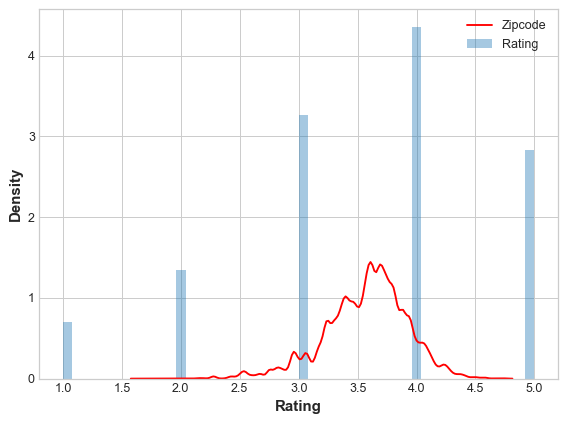

In [ ]:
# Compare the encoded values to the target to see if it offers any further information.
plt.figure(dpi=90)
ax = sns.distplot(y, kde=False, norm_hist=True)
ax = sns.kdeplot(X_train.Zipcode, color='r', ax=ax)
ax.set_xlabel("Rating")
ax.legend(labels=['Zipcode', 'Rating'])